In [ ]:
from pathlib import Path
import shutil

import random
import yaml
import numpy as np
import cv2

import matplotlib.pyplot as plt
from IPython.display import display

from ultralytics import YOLO

In [ ]:
# Resolve dataset location (supports both possible folder names)
workspace_root = Path.cwd()
# candidate_roots = [
#     workspace_root / "DoorAndWindowDetection",
#     workspace_root / "DoorAndWindowDetectionDataset",
# ]

DATASET_ROOT = workspace_root / "DoorAndWindowDetectionDataset"
print(f"dataset location: {DATASET_ROOT}")

DATA_YAML = DATASET_ROOT / "data.yaml"
with open(DATA_YAML, "r") as f:
    base_yaml = yaml.safe_load(f)

# print("Class names from data.yaml:", base_yaml.get("names"))
# print("Class count from data.yaml:", base_yaml.get("nc"))

SPLITS = ["train", "valid", "test"]
for split in SPLITS:
    img_dir = DATASET_ROOT / split / "images"
    lbl_dir = DATASET_ROOT / split / "labels"
    img_count = len(list(img_dir.glob("*"))) if img_dir.exists() else 0
    lbl_count = len(list(lbl_dir.glob("*.txt"))) if lbl_dir.exists() else 0
    # print(f"{split:>5} -> images: {img_count:4d}, labels: {lbl_count:4d}")

dataset location: /Users/homemac/Desktop/other/Here/streetViewCV/yolo-selftrain/DoorAndWindowDetectionDataset


In [ ]:
def parse_label_file(label_path: Path):
    rows = []
    if not label_path.exists():
        return rows
    with open(label_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 5:
                continue
            cls = int(float(parts[0]))
            x, y, w, h = map(float, parts[1:5])
            rows.append((cls, x, y, w, h))
    return rows


test_label_dir = DATASET_ROOT / "test" / "labels"
class_counts = {0: 0, 1: 0}
files_with_door = 0
files_total = 0

for lbl in sorted(test_label_dir.glob("*.txt")):
    files_total += 1
    anns = parse_label_file(lbl)
    has_door = False
    for cls, *_ in anns:
        class_counts[cls] = class_counts.get(cls, 0) + 1
        if cls == 0:
            has_door = True
    if has_door:
        files_with_door += 1

# print("Test annotation counts by class id:", class_counts)
# print(f"Test files with at least one door: {files_with_door}/{files_total}")

In [ ]:

DOOR_DATASET_ROOT = workspace_root / "door_only_dataset"
if DOOR_DATASET_ROOT.exists():
    shutil.rmtree(DOOR_DATASET_ROOT)

for split in SPLITS:
    (DOOR_DATASET_ROOT / split / "images").mkdir(parents=True, exist_ok=True)
    (DOOR_DATASET_ROOT / split / "labels").mkdir(parents=True, exist_ok=True)


def find_image_for_label(label_file: Path, image_dir: Path):
    # Roboflow-style names preserve image extension in the stem (e.g. image_0001_jpg.rf...)
    candidates = list(image_dir.glob(label_file.stem + ".*"))
    if candidates:
        return candidates[0]

    # Fallback: prefix match in case names vary
    prefix = label_file.stem.split(".rf")[0]
    candidates = list(image_dir.glob(prefix + ".*"))
    if candidates:
        return candidates[0]
    return None


split_stats = {}
for split in SPLITS:
    src_img_dir = DATASET_ROOT / split / "images"
    src_lbl_dir = DATASET_ROOT / split / "labels"
    dst_img_dir = DOOR_DATASET_ROOT / split / "images"
    dst_lbl_dir = DOOR_DATASET_ROOT / split / "labels"

    kept_images = 0
    kept_boxes = 0

    for lbl_file in sorted(src_lbl_dir.glob("*.txt")):
        anns = parse_label_file(lbl_file)
        door_anns = [a for a in anns if a[0] == 0]
        if not door_anns:
            continue

        img_file = find_image_for_label(lbl_file, src_img_dir)
        if img_file is None:
            continue

        kept_images += 1
        kept_boxes += len(door_anns)

        shutil.copy2(img_file, dst_img_dir / img_file.name)
        out_lbl = dst_lbl_dir / lbl_file.name
        with open(out_lbl, "w") as f:
            for _, x, y, w, h in door_anns:
                f.write(f"0 {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")

    split_stats[split] = {"images": kept_images, "door_boxes": kept_boxes}

print("Door-only dataset stats:")
for split, st in split_stats.items():
    print(f"{split:>5} -> images: {st['images']:4d}, door boxes: {st['door_boxes']:4d}")

# Write YOLO data config for door-only training
DOOR_DATA_YAML = DOOR_DATASET_ROOT / "door_data.yaml"
with open(DOOR_DATA_YAML, "w") as f:
    yaml.safe_dump(
        {
            "path": str(DOOR_DATASET_ROOT),
            "train": "train/images",
            "val": "valid/images",
            "test": "test/images",
            "nc": 1,
            "names": ["door"],
        },
        f,
        sort_keys=False,
    )

print(f"Wrote: {DOOR_DATA_YAML}")

Door-only dataset stats:
train -> images:  371, door boxes:  662
valid -> images:   74, door boxes:  143
 test -> images:   80, door boxes:  142
Wrote: /Users/homemac/Desktop/other/Here/streetViewCV/yolo-selftrain/door_only_dataset/door_data.yaml


In [ ]:
# Train YOLOv8 on the door-only dataset

# starting with 40 epochs, see later

model = YOLO("yolov9t.pt")

train_results = model.train(
    data=str(DOOR_DATA_YAML),
    epochs=40,
    imgsz=640,
    batch=16,
    project=str(workspace_root / "runs"),
    name="door_yolov9t",
    exist_ok=True,
)

# print("Training complete.")
# print("Best model path:", model.trainer.best)

New https://pypi.org/project/ultralytics/8.4.31 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.12.11 torch-2.10.0 CPU (Apple M2 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/homemac/Desktop/other/Here/streetViewCV/yolo-selftrain/door_only_dataset/door_data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9t.pt, momentum=0.937,

In [ ]:
# Note, took ~90 mins. losses not necessarily observed to plateau, so more epochs could be beneficial

# mAP50-95 appears to plateau around 0.4-0.44 from epoch 20-38, then slight increases after epoch 38.
# mAP50 gradually increases throughout, diminishing growth as it progresses


best_model = YOLO(str(model.trainer.best))
val_results = best_model.val(data=str(DOOR_DATA_YAML), split="val")
print("Validation complete.")
print(val_results)

Ultralytics 8.4.14 🚀 Python-3.12.11 torch-2.10.0 CPU (Apple M2 Pro)
YOLOv9t summary (fused): 197 layers, 1,970,979 parameters, 0 gradients, 7.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 701.8±556.0 MB/s, size: 27.4 KB)
val: Scanning /Users/homemac/Desktop/other/Here/streetViewCV/yolo-selftrain/door_only_dataset/valid/labels.cache... 74 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 74/74 77.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.7s/it 13.3s4.2ss
                   all         74        143      0.754      0.622      0.691      0.493
Speed: 1.1ms preprocess, 175.2ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /Users/homemac/Desktop/other/Here/streetViewCV/yolo-selftrain/runs/detect/val
Validation complete.
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <u

In [ ]:
pred_results = best_model.predict(
    source=str(DOOR_DATASET_ROOT / "test" / "images"),
    conf=0.25,
    iou=0.5,
    save=True,
    save_txt=True,
    save_conf=True,
    project=str(workspace_root / "runs"),
    name="door_test_preds",
    exist_ok=True,
)

PRED_LABEL_DIR = workspace_root / "runs" / "door_test_preds" / "labels"
print(f"Prediction labels directory: {PRED_LABEL_DIR}")
print(f"Saved predictions for {len(pred_results)} test images.")


image 1/80 /Users/homemac/Desktop/other/Here/streetViewCV/yolo-selftrain/door_only_dataset/test/images/image_0003_jpg.rf.5a7a1cafd422d5c7104fce7471137cbc.jpg: 640x640 3 doors, 92.4ms
image 2/80 /Users/homemac/Desktop/other/Here/streetViewCV/yolo-selftrain/door_only_dataset/test/images/image_0004_jpg.rf.0c7f1f4b9eb001e4dd052b5c4d3fcc18.jpg: 640x640 (no detections), 74.8ms
image 3/80 /Users/homemac/Desktop/other/Here/streetViewCV/yolo-selftrain/door_only_dataset/test/images/image_0031_jpg.rf.154588031fcb93f169dd19c282150c78.jpg: 640x640 3 doors, 76.5ms
image 4/80 /Users/homemac/Desktop/other/Here/streetViewCV/yolo-selftrain/door_only_dataset/test/images/image_0034_jpg.rf.7b6d1c7423ee3fab89df8c2ee697b9a0.jpg: 640x640 2 doors, 79.0ms
image 5/80 /Users/homemac/Desktop/other/Here/streetViewCV/yolo-selftrain/door_only_dataset/test/images/image_0070_jpg.rf.4e5211dca13b559e92cf873b86a56e2d.jpg: 640x640 1 door, 72.9ms
image 6/80 /Users/homemac/Desktop/other/Here/streetViewCV/yolo-selftrain/door

In [ ]:

def yolo_xywh_to_xyxy(x, y, w, h):
    x1 = x - w / 2
    y1 = y - h / 2
    x2 = x + w / 2
    y2 = y + h / 2
    return [x1, y1, x2, y2]


def box_iou(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter = inter_w * inter_h

    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter

    if union <= 0:
        return 0.0
    return inter / union


def load_boxes_from_label_file(path, with_conf=False):
    boxes = []
    if not path.exists():
        return boxes
    with open(path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls = int(float(parts[0]))
            x, y, w, h = map(float, parts[1:5])
            conf = float(parts[5]) if (with_conf and len(parts) >= 6) else None
            boxes.append({
                "cls": cls,
                "xyxy": yolo_xywh_to_xyxy(x, y, w, h),
                "conf": conf,
            })
    return boxes


def match_image_boxes(gt_boxes, pred_boxes, iou_thr=0.5):
    pairs = []
    for gi, g in enumerate(gt_boxes):
        for pi, p in enumerate(pred_boxes):
            iou = box_iou(g["xyxy"], p["xyxy"])
            if iou >= iou_thr:
                pairs.append((iou, gi, pi))

    pairs.sort(reverse=True, key=lambda x: x[0])
    matched_gt = set()
    matched_pred = set()
    tp = 0

    for _, gi, pi in pairs:
        if gi in matched_gt or pi in matched_pred:
            continue
        matched_gt.add(gi)
        matched_pred.add(pi)
        tp += 1

    fp = len(pred_boxes) - tp
    fn = len(gt_boxes) - tp
    return tp, fp, fn


gt_dir = DOOR_DATASET_ROOT / "test" / "labels"
pred_dir = PRED_LABEL_DIR

iou_threshold = 0.5
TP = FP = FN = 0

for gt_file in sorted(gt_dir.glob("*.txt")):
    pred_file = pred_dir / gt_file.name
    gt_boxes = load_boxes_from_label_file(gt_file, with_conf=False)
    pred_boxes = load_boxes_from_label_file(pred_file, with_conf=True)

    # Keep only door class (0) predictions in case anything else appears.
    gt_boxes = [b for b in gt_boxes if b["cls"] == 0]
    pred_boxes = [b for b in pred_boxes if b["cls"] == 0]

    tp, fp, fn = match_image_boxes(gt_boxes, pred_boxes, iou_thr=iou_threshold)
    TP += tp
    FP += fp
    FN += fn

precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

print(f"Door detection on test set @ IoU {iou_threshold:.2f}")
print(f"TP={TP}, FP={FP}, FN={FN}")
print(f"Precision={precision:.4f}")
print(f"Recall={recall:.4f}")
print(f"F1={f1:.4f}")

Door detection on test set @ IoU 0.50
TP=92, FP=64, FN=50
Precision=0.5897
Recall=0.6479
F1=0.6174


In [ ]:
def filter_boxes_to_use(boxes, threshold):
    # we dont always want to use all boxes
    
    # if there is only one box, display it anyway whatever
    
    if len(boxes) <= 1:
        return boxes
    
    else:
        
        # many boxes. Which ones should we choose?
        # which is the most confident
        
        best_conf = 0
        
        for box in boxes:
            if (box.get("conf") is not None):
                best_conf = max(box["conf"], best_conf)
        
        retBoxes = []
        for b in boxes:
            if b.get("conf") is not None and b["conf"] >= threshold and b["conf"] >= best_conf - 0.25:
                retBoxes.append(b)
                
        return retBoxes

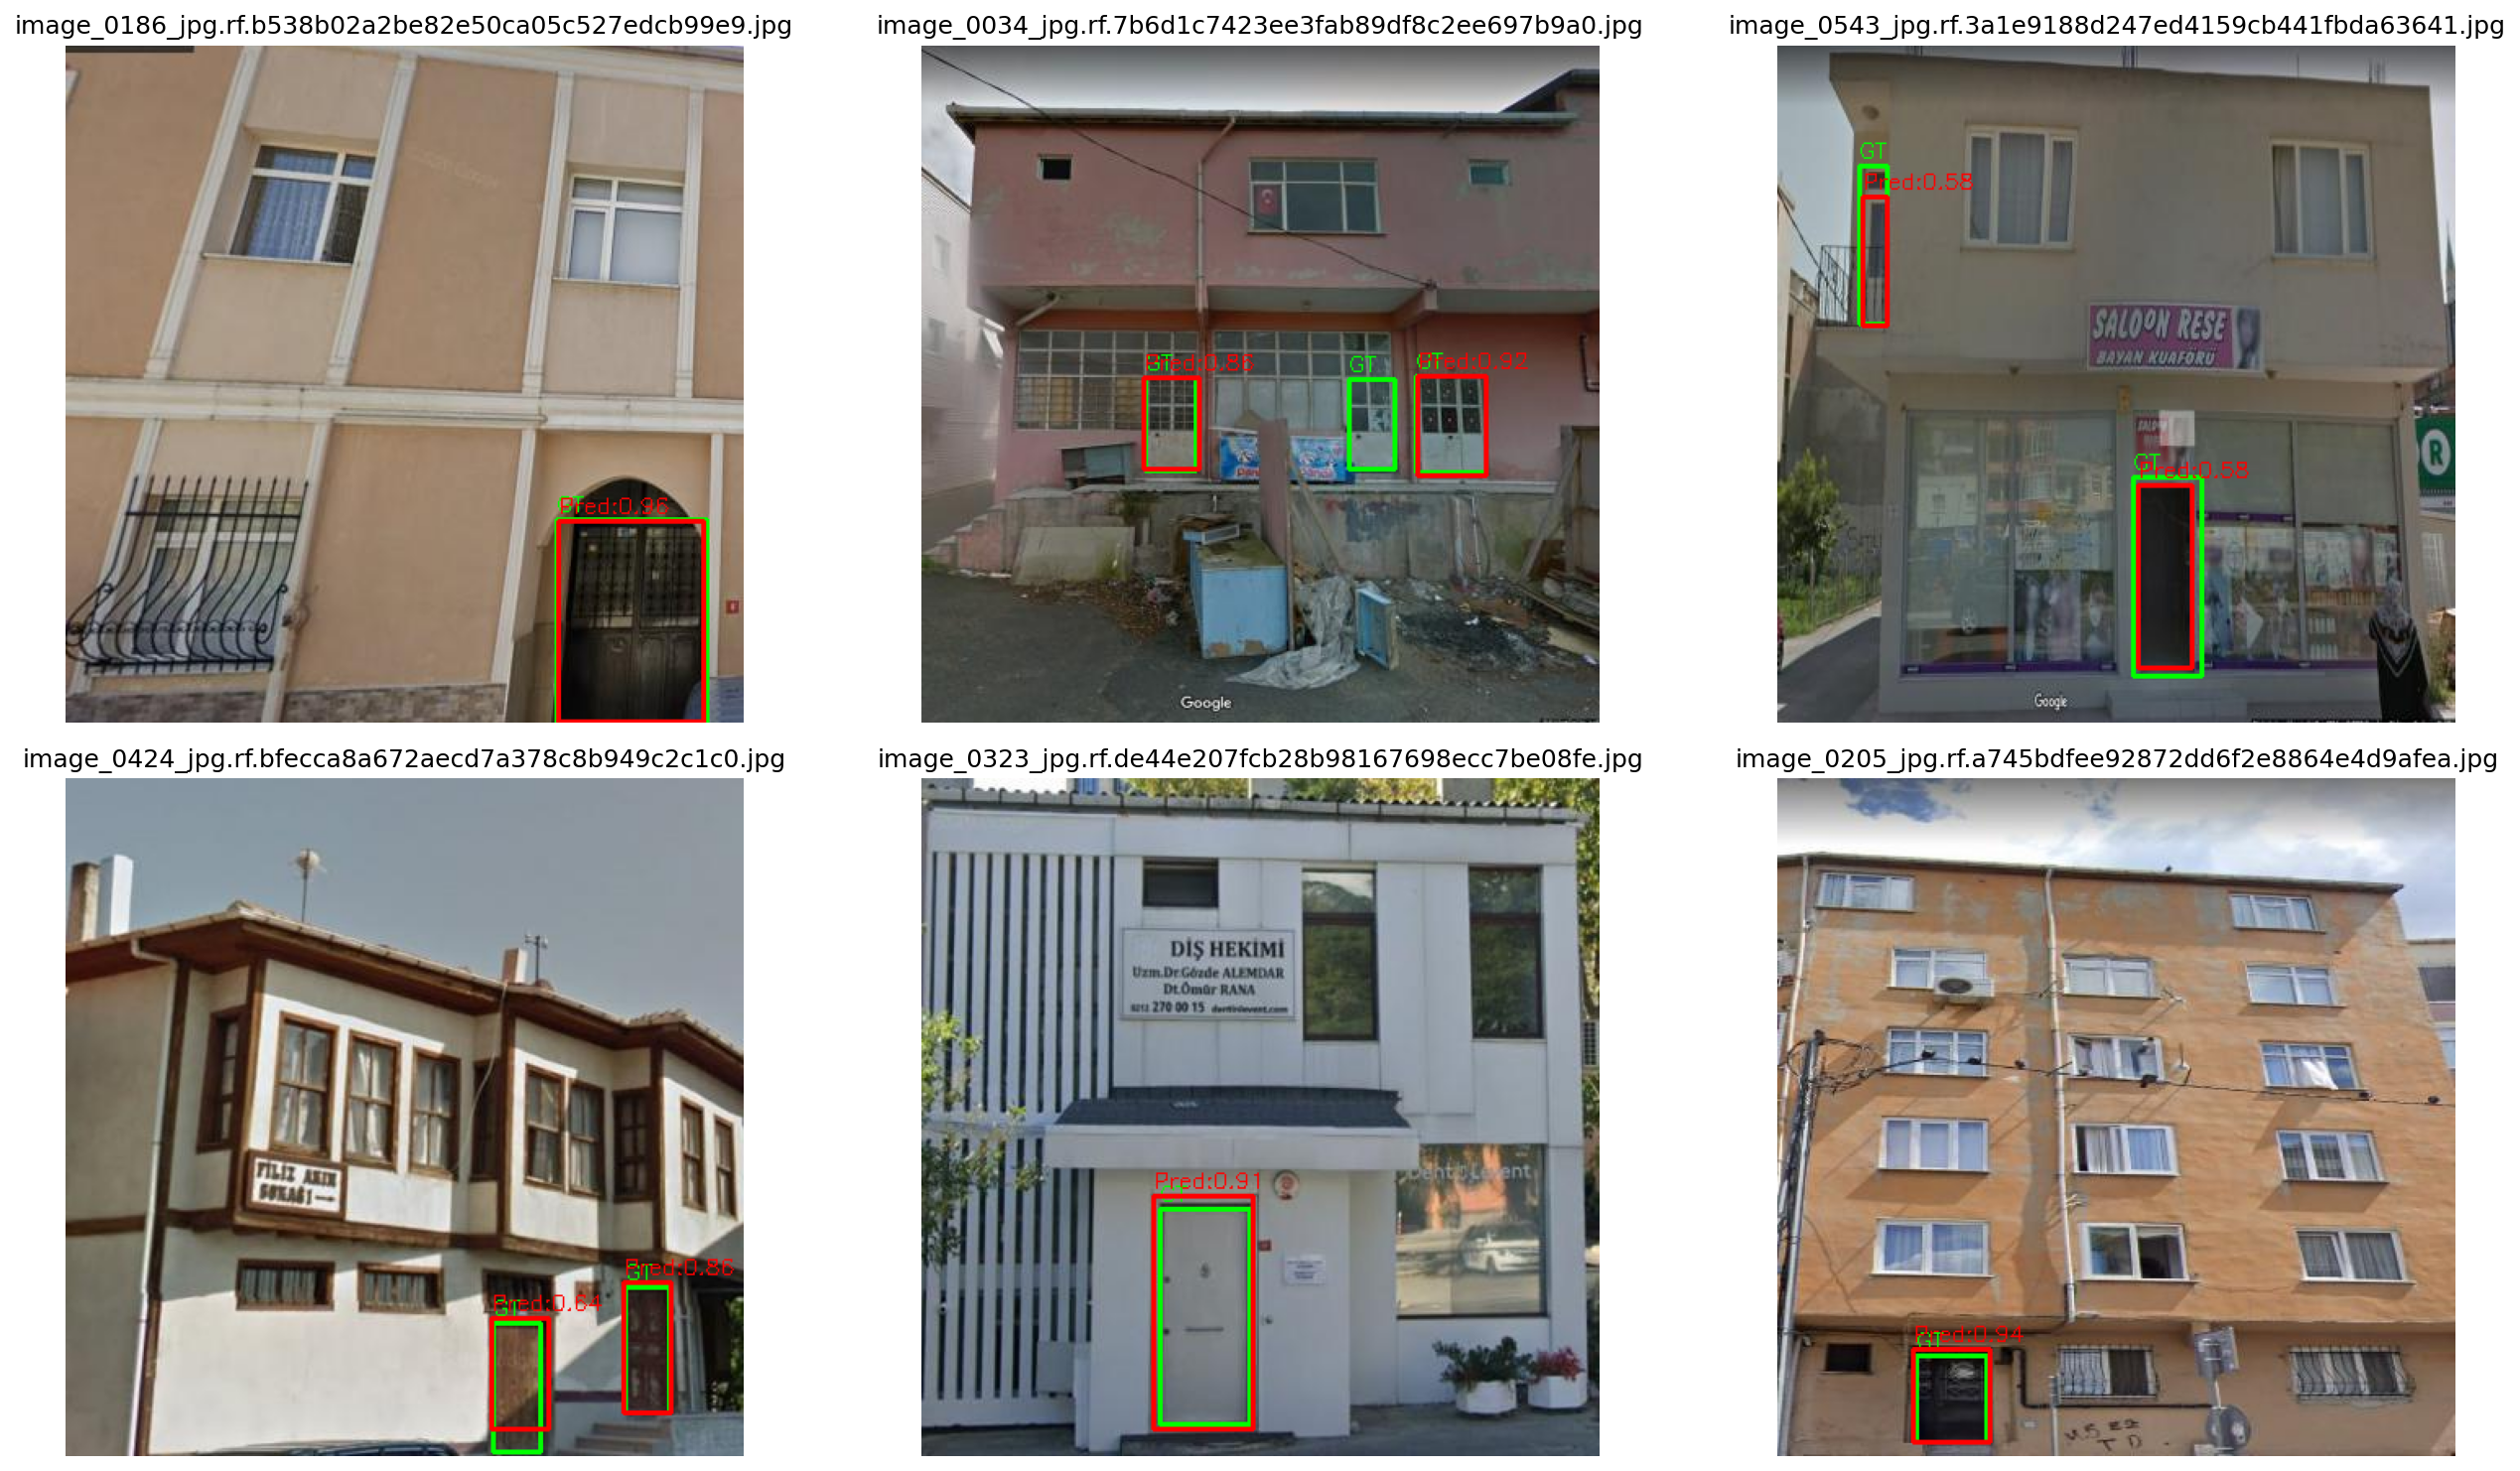

In [ ]:
from io import BytesIO
from IPython.display import Image, display


threshold = 0.55
seed = 42 #random.randint(0, 9999)

def draw_boxes_on_image(image, boxes, color, label_prefix):
    h, w = image.shape[:2]
    
    for b in boxes:
        if (b.get("conf") is not None and b['conf'] < threshold):
            continue
        
        x1n, y1n, x2n, y2n = b["xyxy"]
        x1, y1 = int(x1n * w), int(y1n * h)
        x2, y2 = int(x2n * w), int(y2n * h)
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        txt = label_prefix
        if b.get("conf") is not None:
            txt = f"{label_prefix}:{b['conf']:.2f}"
        cv2.putText(
            image,
            txt,
            (x1, max(0, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            color,
            1,
            cv2.LINE_8,
        )
    return image


test_images = sorted((DOOR_DATASET_ROOT / "test" / "images").glob("*"))
if len(test_images) == 0:
    raise RuntimeError("No test images found in door-only test split.")

random.seed(seed)
show_n = min(6, len(test_images))
samples = random.sample(test_images, show_n)

ncols = 3
nrows = int(np.ceil(show_n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).reshape(-1)

valid_plots = 0
for i, img_path in enumerate(samples):
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        continue

    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    gt_path = DOOR_DATASET_ROOT / "test" / "labels" / (img_path.stem + ".txt")
    pred_path = PRED_LABEL_DIR / (img_path.stem + ".txt")

    gt_boxes = [b for b in load_boxes_from_label_file(gt_path, with_conf=False) if b["cls"] == 0]
    pred_boxes = [b for b in load_boxes_from_label_file(pred_path, with_conf=True) if b["cls"] == 0]

    canvas = img.copy()
    canvas = draw_boxes_on_image(canvas, gt_boxes, color=(0, 255, 0), label_prefix="GT")
    canvas = draw_boxes_on_image(canvas, filter_boxes_to_use(pred_boxes, threshold), color=(255, 0, 0), label_prefix="Pred")

    axes[i].imshow(canvas)
    axes[i].set_title(img_path.name)
    axes[i].axis("off")
    valid_plots += 1

for j in range(valid_plots, len(axes)):
    axes[j].axis("off")

if valid_plots == 0:
    raise RuntimeError("Could not decode sampled images with OpenCV. Check image files.")

plt.tight_layout()
buf = BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(Image(data=buf.getvalue()))